<h1>Training<h1>

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [1]:
import pandas as pd

ts = "20260114_1927"  # your timestamp
df_relevant = pd.read_csv(f"hn_market_relevant_{ts}.csv")

df_relevant.shape, df_relevant.columns

((1013, 13),
 Index(['source', 'keyword', 'content_type', 'objectID', 'created_at', 'author',
        'url', 'story_title', 'text', 'fetched_at', 'clean_text',
        'clean_length', 'is_relevant'],
       dtype='object'))

In [2]:
df_relevant["clean_length"].describe()
df_relevant["keyword"].value_counts().head(10)
df_relevant[["keyword","story_title","clean_text"]].head(3)

,keyword,story_title,clean_text
0,film,Show HN: AlgoMommy – Organize video clips by t...,If you record videos regularly and end up with...
1,film,Show HN: MCP Review – An Open-Source Platform ...,"Hi all, I have just published MCP Review - an ..."
2,film,Show HN: Sovereign GraphGuard – Atomic Persist...,"""I fixed the 'Zombie State' bug in Microsoft A..."


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = df_relevant["clean_text"].tolist()

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=6000,
    ngram_range=(1, 2),
    min_df=3
)

X = vectorizer.fit_transform(texts)
X.shape

(1013, 5258)

In [4]:
from sklearn.cluster import KMeans

k = 8
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
df_relevant["cluster"] = kmeans.fit_predict(X)

df_relevant["cluster"].value_counts()

cluster
2    190
3    167
5    148
1    137
0    126
7    108
4    104
6     33
Name: count, dtype: int64

In [5]:
import numpy as np

terms = np.array(vectorizer.get_feature_names_out())
centroids = kmeans.cluster_centers_

cluster_labels = {}

for i in range(k):
    top_terms = terms[centroids[i].argsort()[::-1][:8]]
    cluster_labels[i] = ", ".join(top_terms)

df_relevant["cluster_label"] = df_relevant["cluster"].map(cluster_labels)

df_relevant[["cluster","cluster_label"]].drop_duplicates().sort_values("cluster")

,cluster,cluster_label
11,0,"monetization, platform, cost, need, like, wind..."
3,1,"built, feedback, love, hn, tools, ai, game, free"
36,2,"don, people, just, like, platform, think, soci..."
9,3,"app, monetization, ads, https, apps, com, user..."
0,4,"github, https, com, api, https github, github ..."
6,5,"ai, just, platform, people, models, ve, video,..."
39,6,"music, ai, bandcamp, slop, platforms, ai music..."
8,7,"code, source, open, platforms, open source, cl..."


In [6]:
CLUSTER_NAME_MAP = {
    0: "Pricing & Monetization Concerns",
    1: "Early Product Feedback & Tool Discovery",
    2: "Platform Perception & Social Sentiment",
    3: "Ad-Based Monetization Trade-offs",
    4: "Developer Ecosystem & Integrations",
    5: "AI Content Platforms & Automation",
    6: "Creator Economy & AI Disruption",
    7: "Open Platform & Trust Signals"
}

df_relevant["market_theme"] = df_relevant["cluster"].map(CLUSTER_NAME_MAP)

In [7]:
df_relevant["market_theme"].value_counts()

market_theme
Platform Perception & Social Sentiment     190
Ad-Based Monetization Trade-offs           167
AI Content Platforms & Automation          148
Early Product Feedback & Tool Discovery    137
Pricing & Monetization Concerns            126
Open Platform & Trust Signals              108
Developer Ecosystem & Integrations         104
Creator Economy & AI Disruption             33
Name: count, dtype: int64

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def top_keywords_by_theme(df, text_col="clean_text", theme_col="market_theme", top_n=10, min_df=3):
    out = []
    for theme, g in df.dropna(subset=[theme_col, text_col]).groupby(theme_col):
        texts = g[text_col].astype(str).tolist()

        vec = TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            min_df=min_df,
            max_features=5000
        )
        X = vec.fit_transform(texts)
        terms = np.array(vec.get_feature_names_out())
        scores = np.asarray(X.mean(axis=0)).ravel()

        top_idx = scores.argsort()[::-1][:top_n]
        out.append({
            "market_theme": theme,
            "top_keywords": ", ".join(terms[top_idx])
        })
    return pd.DataFrame(out).sort_values("market_theme")

theme_keywords = top_keywords_by_theme(df_relevant, top_n=12, min_df=2)
theme_keywords

,market_theme,top_keywords
0,AI Content Platforms & Automation,"ai, just, platform, people, like, monetization..."
1,Ad-Based Monetization Trade-offs,"app, monetization, ads, https, just, com, apps..."
2,Creator Economy & AI Disruption,"music, ai, platforms, bandcamp, platform, peop..."
3,Developer Ecosystem & Integrations,"github, https, api, com, ai, data, agents, pyt..."
4,Early Product Feedback & Tool Discovery,"built, ai, feedback, tools, love, hn, game, ti..."
5,Open Platform & Trust Signals,"code, platforms, open, source, open source, cl..."
6,Platform Perception & Social Sentiment,"people, platform, just, like, don, monetizatio..."
7,Pricing & Monetization Concerns,"monetization, platform, like, people, use, nee..."


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

def representative_quotes(df, text_col="clean_text", theme_col="market_theme", n_quotes=5, min_len=80):
    results = []

    for theme, g in df.dropna(subset=[theme_col, text_col]).groupby(theme_col):
        g = g.copy()
        g = g[g[text_col].astype(str).str.len() >= min_len]
        if len(g) == 0:
            continue

        vec = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2, max_features=8000)
        X = vec.fit_transform(g[text_col].astype(str).tolist())

        centroid = np.asarray(X.mean(axis=0))  # avoid np.matrix issues
        sims = cosine_similarity(X, centroid)
        top_idx = np.argsort(sims.ravel())[::-1][:n_quotes]

        for rank, i in enumerate(top_idx, start=1):
            row = g.iloc[i]
            results.append({
                "market_theme": theme,
                "rank": rank,
                "keyword": row.get("keyword"),
                "story_title": row.get("story_title"),
                "author": row.get("author"),
                "url": row.get("url"),
                "objectID": row.get("objectID"),   # ✅ ADD THIS
                "clean_text": row.get(text_col),
            })

    return pd.DataFrame(results).sort_values(["market_theme", "rank"])

quotes_df = representative_quotes(df_relevant, n_quotes=5)

In [15]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

def theme_stats(df):
    tmp = df.copy()
    tmp["created_at"] = pd.to_datetime(tmp["created_at"], errors="coerce", utc=True)

    stats = (
        tmp.groupby("market_theme")
           .agg(
               mentions=("clean_text", "count"),
               newest=("created_at", "max"),
               oldest=("created_at", "min"),
               unique_authors=("author", "nunique")
           )
           .reset_index()
    )
    stats["days_span"] = (stats["newest"] - stats["oldest"]).dt.days
    stats = stats.sort_values("mentions", ascending=False)
    return stats

def top_signal_phrases(df, theme, text_col="clean_text", top_k=8):
    g = df[df["market_theme"] == theme].copy()
    texts = g[text_col].astype(str).tolist()
    if len(texts) < 3:
        return []

    vec = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=2,
        max_features=8000
    )
    X = vec.fit_transform(texts)
    terms = np.array(vec.get_feature_names_out())

    # average TF-IDF score per term inside this theme
    mean_scores = np.asarray(X.mean(axis=0)).ravel()
    top_idx = np.argsort(mean_scores)[::-1][:top_k]
    return terms[top_idx].tolist()

def top_keywords_for_theme(df, theme, n=3):
    vals = df.loc[df["market_theme"] == theme, "keyword"].dropna().astype(str).tolist()
    if not vals:
        return []
    return [k for k, _ in Counter(vals).most_common(n)]

def build_theme_insights(df_relevant, quotes_df, top_phrases_k=8, top_quotes_k=3):
    stats = theme_stats(df_relevant)

    rows = []
    for _, r in stats.iterrows():
        theme = r["market_theme"]

        phrases = top_signal_phrases(df_relevant, theme, top_k=top_phrases_k)
        top_keys = top_keywords_for_theme(df_relevant, theme, n=3)

        q = quotes_df[quotes_df["market_theme"] == theme].sort_values("rank").head(top_quotes_k)

        # 1–2 sentence auto-insight (template-based, repeatable)
        insight = (
            f"Conversation clusters around {', '.join(phrases[:4]) if phrases else 'recurring product/market themes'}. "
            f"Most mentions appear under keywords: {', '.join(top_keys) if top_keys else 'N/A'}."
        )

        rows.append({
            "market_theme": theme,
            "mentions": int(r["mentions"]),
            "unique_authors": int(r["unique_authors"]),
            "newest": r["newest"],
            "days_span": r["days_span"],
            "top_signal_phrases": ", ".join(phrases),
            "insight_summary": insight,
            "quote_1": q.iloc[0]["clean_text"] if len(q) > 0 else "",
            "quote_1_title": q.iloc[0]["story_title"] if len(q) > 0 else "",
            "quote_1_url": q.iloc[0]["url"] if len(q) > 0 else "",
            "quote_2": q.iloc[1]["clean_text"] if len(q) > 1 else "",
            "quote_2_title": q.iloc[1]["story_title"] if len(q) > 1 else "",
            "quote_2_url": q.iloc[1]["url"] if len(q) > 1 else "",
            "quote_3": q.iloc[2]["clean_text"] if len(q) > 2 else "",
            "quote_3_title": q.iloc[2]["story_title"] if len(q) > 2 else "",
            "quote_3_url": q.iloc[2]["url"] if len(q) > 2 else "",
        })

    return pd.DataFrame(rows).sort_values("mentions", ascending=False).reset_index(drop=True)

insights_df = build_theme_insights(df_relevant, quotes_df, top_phrases_k=8, top_quotes_k=3)
insights_df.head(10)

,market_theme,mentions,unique_authors,newest,days_span,top_signal_phrases,insight_summary,quote_1,quote_1_title,quote_1_url,quote_2,quote_2_title,quote_2_url,quote_3,quote_3_title,quote_3_url
0,Platform Perception & Social Sentiment,190,182,2026-01-14 19:12:38+00:00,499,"people, platform, just, like, don, monetizatio...","Conversation clusters around people, platform,...",I have been a small content creator for 10 yea...,How to stay sane in a world that rewards insanity,https://news.ycombinator.com/item?id=45982300,"I used the early web. I miss forums, I miss th...",A website to destroy all websites,https://news.ycombinator.com/item?id=46458289,"It's certainly a very profitable industry, I d...",Influencers and OnlyFans models are dominating...,https://news.ycombinator.com/item?id=46613005
1,Ad-Based Monetization Trade-offs,167,162,2026-01-14 19:08:30+00:00,697,"app, monetization, ads, https, just, com, apps...","Conversation clusters around app, monetization...","I built Libris.fm[1] , it's a free iOS app wri...",Ask HN: How do we improve the discovery of app...,https://news.ycombinator.com/item?id=43893380,"Hello everyone, I’ve had a NAS for well over 1...",Show HN: I created a 100% 3D printed and tooll...,https://news.ycombinator.com/item?id=40093018,"Hi All, A couple of days ago I posted (https:/...",Ask HN: How to increase users and awareness fo...,https://news.ycombinator.com/item?id=43549082
2,AI Content Platforms & Automation,148,146,2026-01-14 19:00:27+00:00,703,"ai, just, platform, people, like, monetization...","Conversation clusters around ai, just, platfor...",Not every startup can afford to burn cash for ...,How to get an initial user base for a consumer...,https://news.ycombinator.com/item?id=43821259,"We just launched Datta AI, a new platform that...",Show HN: Datta AI – Get paid when your data tr...,https://www.dattaai.com,"> Even if its just creative prompting, or perh...",AI generated music barred from Bandcamp,https://news.ycombinator.com/item?id=46613021
3,Early Product Feedback & Tool Discovery,137,132,2026-01-14 19:08:54+00:00,706,"built, ai, feedback, tools, love, hn, game, time","Conversation clusters around built, ai, feedba...",Launching my first product today and would lov...,Launched: Free AI embeddings for developers wh...,https://news.ycombinator.com/item?id=46492939,"Hi HN, I’m building Blurble (https://[your-dom...",Blurble – An anonymous confessions feed to com...,https://news.ycombinator.com/item?id=46208482,This might be a bit of an unconventional Show ...,A pink aesthetic wallpaper hub for makers/crea...,https://news.ycombinator.com/item?id=46599320
4,Pricing & Monetization Concerns,126,123,2026-01-14 18:56:18+00:00,707,"monetization, platform, like, people, use, nee...","Conversation clusters around monetization, pla...",> What's missing from these parts which makes ...,The U.S. Government Just Followed Through on I...,https://news.ycombinator.com/item?id=46606491,I spent the last 18 months building Primordia ...,A 3-Layer Cognitive Architecture with Append-O...,https://news.ycombinator.com/item?id=46556624,Though I think it's a very steep sigmoid that ...,"Let's be honest, Generative AI isn't going all...",https://news.ycombinator.com/item?id=46611708
5,Open Platform & Trust Signals,108,103,2026-01-14 18:38:46+00:00,569,"code, platforms, open, source, open source, cl...","Conversation clusters around code, platforms, ...",Note: Use code SHOWHNFREE to get it for free. ...,Show HN: Visualize full Claude Code CLI sessio...,https://rcanand.gumroad.com/l/ccviewer,> This article is lame. How about focusing on ...,Self-hosting is being enshittified,https://news.ycombinator.com/item?id=46417458,I've never once had someone tell me they enjoy...,"Ask HN: Is this the end of the ""no code platfo...",https://news.ycombinator.com/item?id=46515459
6,Developer Ecosystem & Integrations,104,95,2026-01-14 18:23:45+00:00,687,"github, https, api, com, ai, data, agents, python","Conversation clusters around gi

In [16]:
def add_hn_item_url(df, objectid_col="objectID", url_col="url"):
    df = df.copy()
    hn_link = "https://news.ycombinator.com/item?id=" + df[objectid_col].astype(str)
    df[url_col] = df[url_col].fillna(hn_link)
    return df

# Apply to both
df_relevant = add_hn_item_url(df_relevant)
quotes_df = add_hn_item_url(quotes_df, objectid_col="objectID", url_col="url")  # if objectID exists in quotes_df

In [17]:
PAIN_TERMS = ["pain", "problem", "issue", "friction", "hard", "difficult", "annoy", "broken", "slow", "confusing"]
OPP_TERMS  = ["need", "want", "wish", "should", "could", "opportunity", "missing", "gap", "would pay", "request"]
RISK_TERMS = ["trust", "privacy", "scam", "fraud", "ban", "legal", "policy", "compliance", "risk", "unsafe"]

def extract_signal_sentences(text, terms, max_sentences=3):
    if not isinstance(text, str):
        return []
    sents = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if len(s.strip()) > 20]
    hits = []
    for s in sents:
        s_low = s.lower()
        if any(t in s_low for t in terms):
            hits.append(s)
        if len(hits) >= max_sentences:
            break
    return hits

def build_actionable_insights(df, theme, n_samples=60):
    g = df[df["market_theme"] == theme].copy()
    g = g.sample(min(len(g), n_samples), random_state=42)

    pains, opps, risks = [], [], []
    for t in g["clean_text"].astype(str).tolist():
        pains += extract_signal_sentences(t, PAIN_TERMS, 1)
        opps  += extract_signal_sentences(t, OPP_TERMS, 1)
        risks += extract_signal_sentences(t, RISK_TERMS, 1)

    def top_unique(lst, k=3):
        out = []
        seen = set()
        for x in lst:
            x2 = x[:220]
            if x2.lower() not in seen:
                out.append(x2)
                seen.add(x2.lower())
            if len(out) >= k:
                break
        return out

    return {
        "pain_signals": " | ".join(top_unique(pains, 3)),
        "opportunity_signals": " | ".join(top_unique(opps, 3)),
        "risk_signals": " | ".join(top_unique(risks, 3)),
    }

In [18]:
import re

insights_df = insights_df.copy()

signals = []
for theme in insights_df["market_theme"]:
    signals.append(build_actionable_insights(df_relevant, theme))

signals_df = pd.DataFrame(signals)
insights_df = pd.concat([insights_df, signals_df], axis=1)

insights_df[["market_theme","mentions","pain_signals","opportunity_signals","risk_signals"]].head()

,market_theme,mentions,pain_signals,opportunity_signals,risk_signals
0,Platform Perception & Social Sentiment,190,The core issues are auditability and evidentia...,"Napkins are back at the diner, and now they're...",Sounds like they should be banning their sale ...
1,Ad-Based Monetization Trade-offs,167,https://receipts2csv.streamlit.app/ Problem St...,"If you are lazy like I am, you could accumulat...",The US banned Thierry Breton a few weeks ago[0...
2,AI Content Platforms & Automation,148,Details on the Known Limitations page: https:/...,"I'm fact, IMO, it should have been one of the ...",AI use in scams has also become common place. ...
3,Early Product Feedback & Tool Discovery,137,"Contributions, ideas, and feedback are very we...",Would love feedback on the UX and any tools yo...,Process sensitive data without worrying about ...
4,Pricing & Monetization Concerns,126,I've been working on the software side of the ...,You need to 2x+ the transportation cost of all...,"Hi HN, I’m researching how early-stage startup..."


In [19]:
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

def strip_urls(text: str) -> str:
    text = re.sub(r"http\S+|www\.\S+", "", str(text))
    text = re.sub(r"\s+", " ", text).strip()
    return text

def split_sentences(text: str):
    text = strip_urls(text)
    # basic sentence split (good enough for HN comments)
    sents = re.split(r"(?<=[.!?])\s+", text)
    # keep reasonable sentences
    sents = [s.strip() for s in sents if 40 <= len(s.strip()) <= 240]
    return sents

In [20]:
PAIN_WORDS = [
    "problem", "pain", "hard", "difficult", "friction", "confusing", "broken",
    "hate", "annoy", "struggle", "fails", "issue", "limitation", "slow"
]

OPPORTUNITY_WORDS = [
    "opportunity", "could", "should", "would", "improve", "better", "build",
    "need", "demand", "use case", "workflow", "automate", "simplify", "value"
]

RISK_WORDS = [
    "risk", "concern", "legal", "privacy", "scam", "fraud", "ban", "abuse",
    "unsafe", "security", "trust", "misuse", "policy", "compliance"
]

def contains_any(sent, words):
    s = sent.lower()
    return any(w in s for w in words)

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

def build_actionable_insights(
    df_relevant,
    theme,
    theme_col="market_theme",
    text_col="clean_text",
    n_each=3,
    max_rows=600
):
    g = df_relevant[df_relevant[theme_col] == theme].copy()
    if g.empty:
        return {"pain_signals": "", "opportunity_signals": "", "risk_signals": ""}

    # limit rows for speed
    g = g.sample(min(len(g), max_rows), random_state=42)

    # expand into sentence-level table
    rows = []
    for _, r in g.iterrows():
        for s in split_sentences(r.get(text_col, "")):
            rows.append({"sent": s, "keyword": r.get("keyword"), "objectID": r.get("objectID")})
    sent_df = pd.DataFrame(rows).drop_duplicates(subset=["sent"])
    if sent_df.empty:
        return {"pain_signals": "", "opportunity_signals": "", "risk_signals": ""}

    # rank sentences by "theme centrality" using TF-IDF centroid similarity
    vec = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2, max_features=12000)
    X = vec.fit_transform(sent_df["sent"].astype(str).tolist())
    centroid = np.asarray(X.mean(axis=0))
    sims = cosine_similarity(X, centroid).ravel()
    sent_df["score"] = sims

    # helper to pick top N matching category with good score
    def pick_top(mask_words):
        subset = sent_df[sent_df["sent"].apply(lambda s: contains_any(s, mask_words))].copy()
        if subset.empty:
            return []
        subset = subset.sort_values("score", ascending=False)
        # return top unique-ish sentences
        out = []
        for s in subset["sent"].tolist():
            if all(s.lower() not in x.lower() for x in out):
                out.append(s)
            if len(out) >= n_each:
                break
        return out

    pain = pick_top(PAIN_WORDS)
    opp = pick_top(OPPORTUNITY_WORDS)
    risk = pick_top(RISK_WORDS)

    # fallback if lexicon match is weak: just top central sentences
    def fallback():
        top = sent_df.sort_values("score", ascending=False)["sent"].head(n_each).tolist()
        return top

    if len(pain) == 0: pain = fallback()
    if len(opp) == 0:  opp  = fallback()
    if len(risk) == 0: risk = fallback()

    # join as bullet-like strings (clean + readable)
    def fmt(lst):
        return " | ".join(lst[:n_each])

    return {
        "pain_signals": fmt(pain),
        "opportunity_signals": fmt(opp),
        "risk_signals": fmt(risk)
    }

In [44]:
# keep only the last occurrence of duplicate column names
insights_df = insights_df.loc[:, ~insights_df.columns.duplicated(keep="last")].copy()

insights_df.columns

Index(['market_theme', 'mentions', 'unique_authors', 'newest', 'days_span',
       'top_signal_phrases', 'insight_summary', 'quote_1', 'quote_1_title',
       'quote_1_url', 'quote_2', 'quote_2_title', 'quote_2_url', 'quote_3',
       'quote_3_title', 'quote_3_url', 'pain_signals', 'opportunity_signals',
       'risk_signals'],
      dtype='object')

In [45]:
def split_sentences(text: str):
    text = str(text)

    # drop URLs before splitting
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # split
    sents = re.split(r"(?<=[.!?])\s+", text)

    # filter
    out = []
    for s in sents:
        s = re.sub(r"\s+", " ", s).strip()
        if 40 <= len(s) <= 240 and "hn:" not in s.lower():
            out.append(s)
    return out

In [46]:
# normalize column names (removes trailing/leading spaces)
insights_df.columns = insights_df.columns.astype(str).str.strip()

# drop duplicate columns by name (keep first)
insights_df = insights_df.loc[:, ~insights_df.columns.duplicated(keep="first")].copy()

In [47]:
insights_df.columns[insights_df.columns.duplicated()].tolist()

[]

In [48]:
# 1) Remove existing signal cols if they already exist
signal_cols = ["pain_signals", "opportunity_signals", "risk_signals"]
insights_df = insights_df.drop(columns=[c for c in signal_cols if c in insights_df.columns], errors="ignore").copy()

# 2) Rebuild signals
signals = [build_actionable_insights(df_relevant, theme) for theme in insights_df["market_theme"]]
signals_df = pd.DataFrame(signals)

# 3) Add them back (cleanly)
insights_df = pd.concat([insights_df.reset_index(drop=True), signals_df.reset_index(drop=True)], axis=1)

# check
insights_df[["market_theme","mentions","pain_signals","opportunity_signals","risk_signals"]].head()

,market_theme,mentions,pain_signals,opportunity_signals,risk_signals
0,Platform Perception & Social Sentiment,190,The problem for some people is that they want ...,The motivational one imho is very real but the...,Essentially large platforms should not be allo...
1,Ad-Based Monetization Trade-offs,167,"Like, no ads, no in-app purchases, and focused...",With their recent push toward monetization and...,No subscription trap – one-time purchase philo...
2,AI Content Platforms & Automation,148,"At the core, the answer to the problem seems o...",They are utterly complicit in a way they would...,"With this said, this may be more of a reason t..."
3,Early Product Feedback & Tool Discovery,137,"Hi HN, I built Roast Feast as a solo dev proje...",I'd love feedback on how creators are using it...,"We built ViviGener, a free community platform ..."
4,Pricing & Monetization Concerns,126,I’ve seen platforms like Business-Tester used ...,I think they need to design a long-term moneti...,"But to your point, developing research, drugs,..."


In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

PAIN_CUES = ["problem", "pain", "hard", "difficult", "issue", "friction", "struggle", "can't", "cannot", "doesn't", "limited", "worse", "annoying"]
OPP_CUES  = ["opportunity", "could", "should", "idea", "solution", "improve", "better", "build", "launch", "workflow", "automate", "use case"]
RISK_CUES = ["risk", "scam", "fraud", "abuse", "ban", "policy", "illegal", "privacy", "unsafe", "compliance", "attack", "harm"]

def _best_sentence(sentences, cue_words, fallback_sentences=None):
    if not sentences:
        return ""

    # Prefer sentences that contain cue-words
    cue = [s for s in sentences if any(w in s.lower() for w in cue_words)]
    pool = cue if len(cue) >= 3 else sentences  # if too few, use all

    # Score by TF-IDF centroid similarity (most representative)
    vec = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=1, max_features=5000)
    X = vec.fit_transform(pool)
    centroid = np.asarray(X.mean(axis=0))
    sims = (X @ centroid.T).toarray().ravel()
    return pool[int(np.argmax(sims))]

def build_actionable_insights(df, theme, text_col="clean_text"):
    g = df[df["market_theme"] == theme].copy()
    all_sents = []
    for t in g[text_col].astype(str).tolist():
        all_sents.extend(split_sentences(t))

    # keep some variety
    all_sents = list(dict.fromkeys(all_sents))  # de-dup while preserving order

    pain = _best_sentence(all_sents, PAIN_CUES)
    opp  = _best_sentence(all_sents, OPP_CUES)
    risk = _best_sentence(all_sents, RISK_CUES)

    return {
        "pain_signals": pain,
        "opportunity_signals": opp,
        "risk_signals": risk
    }

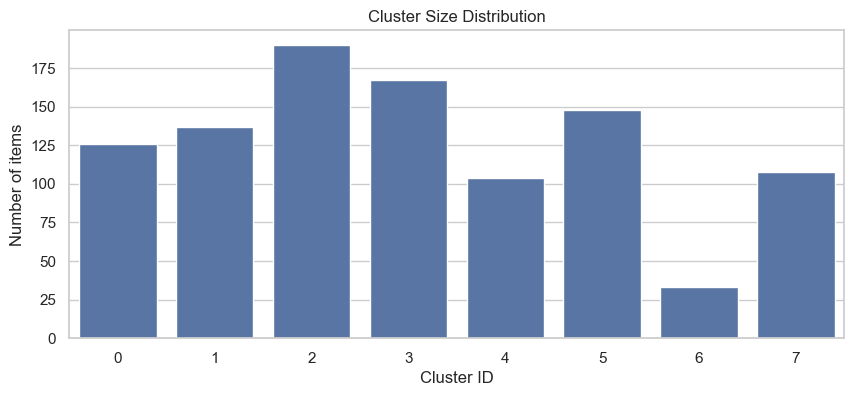

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df_relevant.copy()

cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(10,4))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster ID")
plt.ylabel("Number of items")
plt.show()

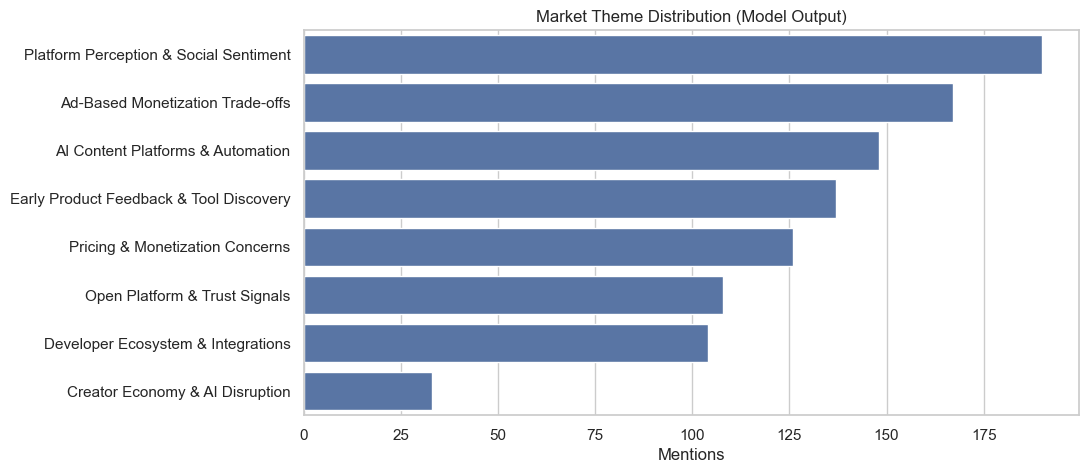

In [53]:
theme_counts = df["market_theme"].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(y=theme_counts.index, x=theme_counts.values)
plt.title("Market Theme Distribution (Model Output)")
plt.xlabel("Mentions")
plt.ylabel("")
plt.show()

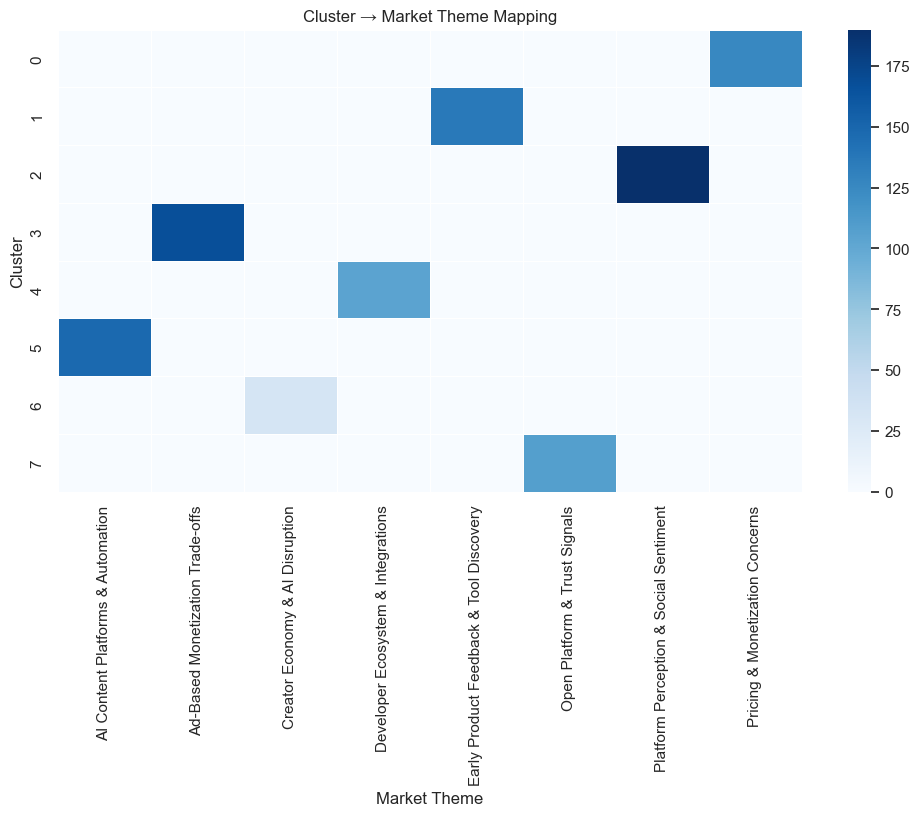

In [54]:
ct = pd.crosstab(df["cluster"], df["market_theme"])

plt.figure(figsize=(12,6))
sns.heatmap(ct, cmap="Blues", linewidths=0.5)
plt.title("Cluster → Market Theme Mapping")
plt.xlabel("Market Theme")
plt.ylabel("Cluster")
plt.show()

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

def top_terms_by_theme(df, theme_col="market_theme", text_col="clean_text", top_n=12):
    out = []
    for theme, g in df.groupby(theme_col):
        vec = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2, max_features=8000)
        X = vec.fit_transform(g[text_col].astype(str))
        mean_tfidf = np.asarray(X.mean(axis=0)).ravel()
        terms = np.array(vec.get_feature_names_out())
        top_idx = mean_tfidf.argsort()[::-1][:top_n]
        out.append((theme, terms[top_idx].tolist()))
    return pd.DataFrame(out, columns=["market_theme","top_terms"])

top_terms_df = top_terms_by_theme(df)
top_terms_df

,market_theme,top_terms
0,AI Content Platforms & Automation,"[ai, just, platform, people, like, monetizatio..."
1,Ad-Based Monetization Trade-offs,"[app, monetization, ads, https, just, com, app..."
2,Creator Economy & AI Disruption,"[music, ai, platforms, bandcamp, platform, peo..."
3,Developer Ecosystem & Integrations,"[github, https, api, com, ai, data, agents, py..."
4,Early Product Feedback & Tool Discovery,"[built, ai, feedback, tools, love, hn, game, t..."
5,Open Platform & Trust Signals,"[code, platforms, open, source, open source, c..."
6,Platform Perception & Social Sentiment,"[people, platform, just, like, don, monetizati..."
7,Pricing & Monetization Concerns,"[monetization, platform, like, people, use, ne..."


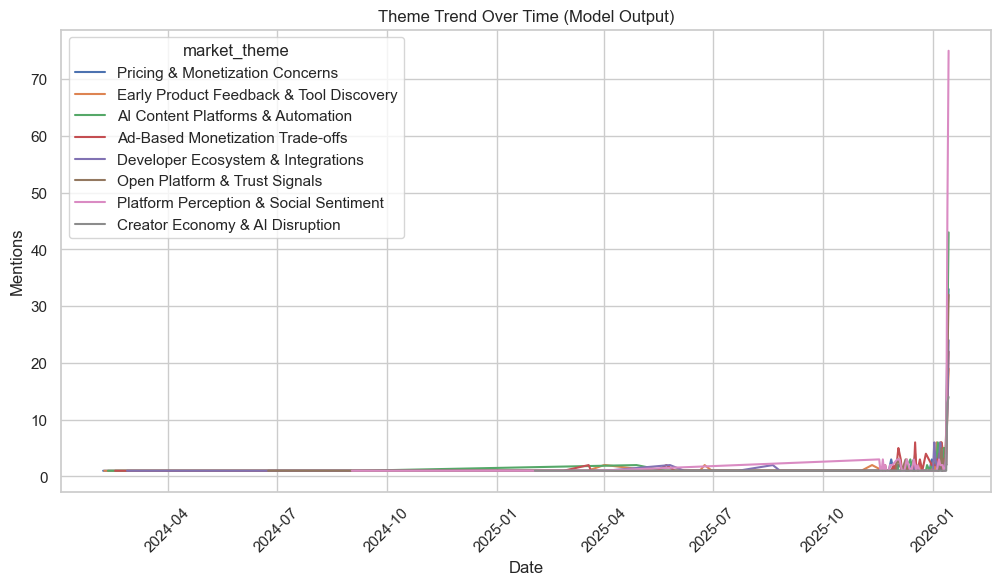

In [56]:
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
df["date"] = df["created_at"].dt.date

trend = (
    df.groupby(["date","market_theme"])
      .size()
      .reset_index(name="count")
)

plt.figure(figsize=(12,6))
sns.lineplot(data=trend, x="date", y="count", hue="market_theme")
plt.title("Theme Trend Over Time (Model Output)")
plt.xlabel("Date")
plt.ylabel("Mentions")
plt.xticks(rotation=45)
plt.show()

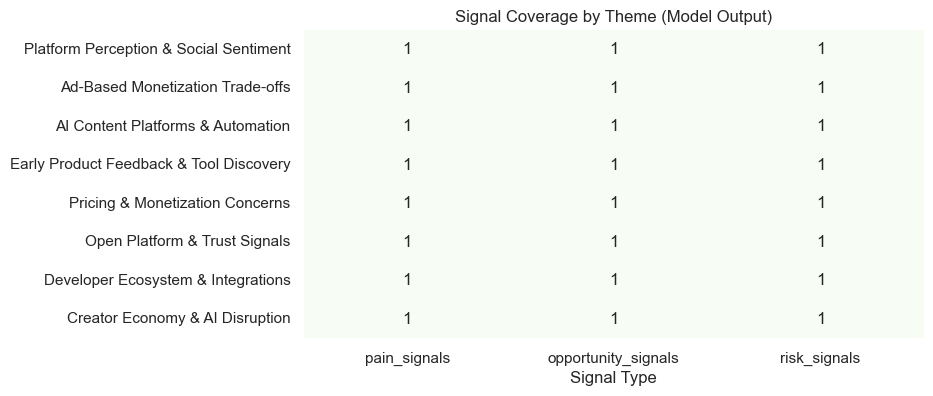

In [57]:
signal_presence = insights_df.copy()

for c in ["pain_signals","opportunity_signals","risk_signals"]:
    signal_presence[c] = signal_presence[c].astype(str).str.len().gt(10).astype(int)

signal_presence = signal_presence.set_index("market_theme")[["pain_signals","opportunity_signals","risk_signals"]]

plt.figure(figsize=(8,4))
sns.heatmap(signal_presence, annot=True, cmap="Greens", cbar=False)
plt.title("Signal Coverage by Theme (Model Output)")
plt.xlabel("Signal Type")
plt.ylabel("")
plt.show()

/var/folders/sy/tv3v7f_x7s9g4tkz_4d624gm0000gn/T/ipykernel_9890/3702720830.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ]].applymap(signal_count)


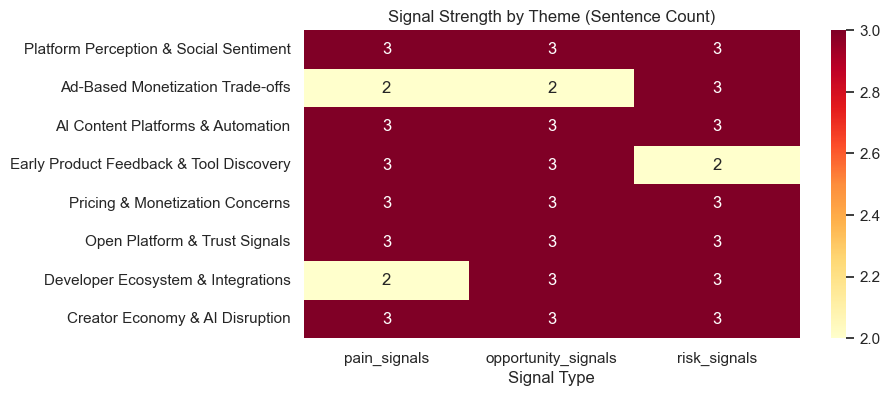

In [58]:
def signal_count(x):
    return len(split_sentences(x)) if isinstance(x, str) else 0

signal_strength = insights_df.set_index("market_theme")[[
    "pain_signals",
    "opportunity_signals",
    "risk_signals"
]].applymap(signal_count)

plt.figure(figsize=(8,4))
sns.heatmap(signal_strength, annot=True, cmap="YlOrRd")
plt.title("Signal Strength by Theme (Sentence Count)")
plt.xlabel("Signal Type")
plt.ylabel("")
plt.show()

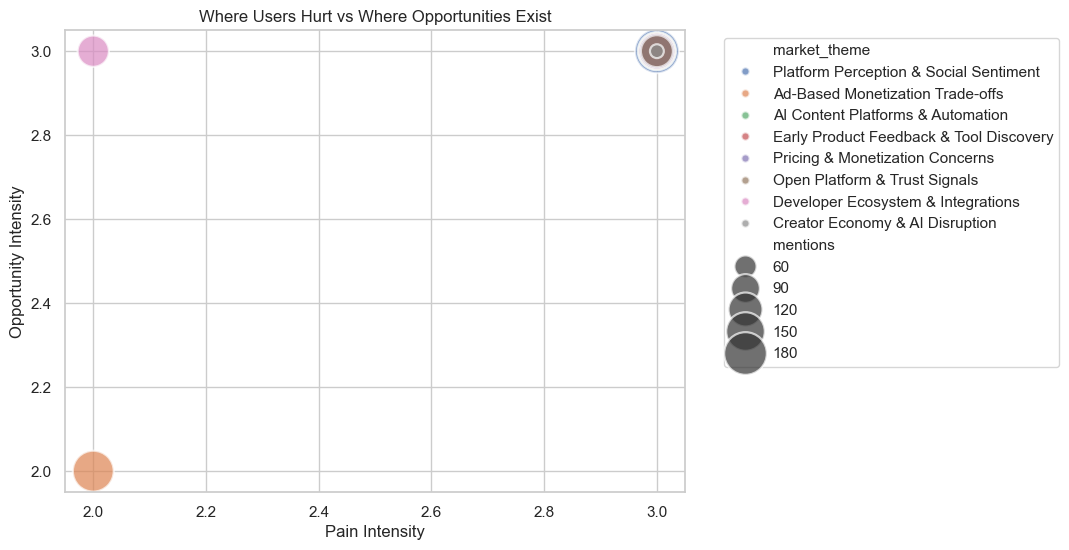

In [59]:
def signal_score(text):
    if not isinstance(text, str):
        return 0
    return len(split_sentences(text))

viz_df = insights_df.copy()
viz_df["pain_score"] = viz_df["pain_signals"].apply(signal_score)
viz_df["opportunity_score"] = viz_df["opportunity_signals"].apply(signal_score)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=viz_df,
    x="pain_score",
    y="opportunity_score",
    size="mentions",
    hue="market_theme",
    sizes=(100, 1000),
    alpha=0.7
)

plt.title("Where Users Hurt vs Where Opportunities Exist")
plt.xlabel("Pain Intensity")
plt.ylabel("Opportunity Intensity")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

/var/folders/sy/tv3v7f_x7s9g4tkz_4d624gm0000gn/T/ipykernel_9890/1356797530.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


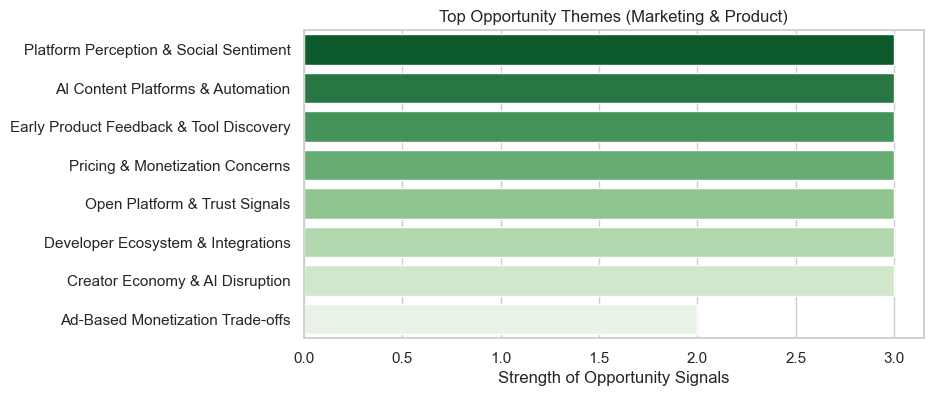

In [60]:
opp_rank = insights_df.copy()
opp_rank["opportunity_score"] = opp_rank["opportunity_signals"].apply(signal_score)

opp_rank = opp_rank.sort_values("opportunity_score", ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(
    data=opp_rank,
    y="market_theme",
    x="opportunity_score",
    palette="Greens_r"
)

plt.title("Top Opportunity Themes (Marketing & Product)")
plt.xlabel("Strength of Opportunity Signals")
plt.ylabel("")
plt.show()

In [61]:
def collect_theme_sentences(df, theme, text_col="clean_text"):
    g = df[df["market_theme"] == theme]
    sentences = []
    for t in g[text_col].astype(str):
        sentences.extend(split_sentences(t))
    return list(dict.fromkeys(sentences))  # dedupe
    

In [62]:
SIGNAL_WORDS = [
    "problem","pain","hard","difficult","issue","frustrat",
    "need","gap","missing","lack",
    "opportunity","should","could","better","build","improve",
    "monetization","pricing","workflow","platform","creator"
]

def signal_score(sentence):
    s = sentence.lower()
    return sum(1 for w in SIGNAL_WORDS if w in s)

In [63]:
all_sentences = []

for theme in df_relevant["market_theme"].unique():
    sents = collect_theme_sentences(df_relevant, theme)
    for s in sents:
        all_sentences.append({
            "sentence": s,
            "theme": theme,
            "score": signal_score(s)
        })

sent_df = pd.DataFrame(all_sentences)
sent_df = sent_df[sent_df["score"] > 0]
sent_df = sent_df.sort_values("score", ascending=False)

In [64]:
final_sentences = []
used_themes = set()

for _, row in sent_df.iterrows():
    if len(final_sentences) == 5:
        break
    if row["theme"] not in used_themes:
        final_sentences.append(row["sentence"])
        used_themes.add(row["theme"])

final_sentences

["GitHub: Demo video: The Problem: We've been building AI workflows for the past year and kept running into the same issue: existing platforms (n8n, Langflow, Flowise) require full access to your Google services even for read-only operations.",
 "i do wonder how hard it would be to integrate multiple of these APIs so that the end user could invite anyone from any platform, though i imagine you'll still need some sort of middle man / lobby server...",
 "All of this is true, but it's a problem of the entire web platform and specs, so if you want to favor untraceability above compatibility, you'll need a dedicated privacy-hardened browser.",
 'I wanted a single platform where creators could pick the right model for their needs: fast/cheap for drafts, high-quality for final output.',
 "I'm considering developing a free, ad-free online platform to help families manage medical information and improve communication with healthcare providers—completely non-profit, with no monetization involved

In [65]:
for i, s in enumerate(final_sentences, start=1):
    print(f"{i}. {s}")

1. GitHub: Demo video: The Problem: We've been building AI workflows for the past year and kept running into the same issue: existing platforms (n8n, Langflow, Flowise) require full access to your Google services even for read-only operations.
2. i do wonder how hard it would be to integrate multiple of these APIs so that the end user could invite anyone from any platform, though i imagine you'll still need some sort of middle man / lobby server...
3. All of this is true, but it's a problem of the entire web platform and specs, so if you want to favor untraceability above compatibility, you'll need a dedicated privacy-hardened browser.
4. I wanted a single platform where creators could pick the right model for their needs: fast/cheap for drafts, high-quality for final output.
5. I'm considering developing a free, ad-free online platform to help families manage medical information and improve communication with healthcare providers—completely non-profit, with no monetization involved.
